In [18]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from pandas.plotting import table

df = pd.read_csv(r'C:\Users\SéamusPeareBartholdy\Documents\GitHub\AC-Horsens-First-Team\DNK_1_Division_2024_2025\matchstats_all DNK_1_Division_2024_2025.csv')
df_xg = pd.read_csv(r'C:\Users\SéamusPeareBartholdy\Documents\GitHub\AC-Horsens-First-Team\DNK_1_Division_2024_2025\xg_all DNK_1_Division_2024_2025.csv')
df_xg = df_xg.groupby(['contestantId', 'label','date','match_id'])['321'].sum().reset_index()
df = df.merge(df_xg,on=['contestantId','label','date','match_id'])
df_xa = pd.read_csv(r'C:\Users\SéamusPeareBartholdy\Documents\GitHub\AC-Horsens-First-Team\DNK_1_Division_2024_2025\xA_all DNK_1_Division_2024_2025.csv')
df_xa = df_xa.groupby(['contestantId','team_name','label','match_id'])['318.0'].sum().reset_index()
df = df.merge(df_xa,on=['contestantId','label','match_id'])
df_pv = pd.read_csv(r'C:\Users\SéamusPeareBartholdy\Documents\GitHub\AC-Horsens-First-Team\DNK_1_Division_2024_2025\pv_all DNK_1_Division_2024_2025.csv')
df_pv = df_pv.groupby(['team_name','label','date'])['possessionValue.pvValue'].sum().reset_index()
df = df.merge(df_pv,on=['team_name','label','date'])
df = df[['team_name', 'label', 'date', 'match_id', 'penAreaEntries', 'successfulOpenPlayPass', 
         'openPlayPass', 'totalFwdZonePass', 'accurateFwdZonePass', 'finalThirdEntries', 
         'successfulFinalThirdPasses', 'possLostAll', 'touchesInOppBox', 'totalCrossNocorner', 
         'interceptionWon', '321', '318.0', 'possessionValue.pvValue']]

# List of columns to sum
exclude_columns = ['team_name', 'label', 'date', 'match_id', '321', '318.0', 'possessionValue.pvValue']
columns_to_sum = [col for col in df.columns if col not in exclude_columns]

# Group by 'match_id', 'team_name', 'label', 'date' and apply aggregation
df = df.groupby(['match_id', 'team_name', 'label', 'date']).agg(
    {**{col: 'sum' for col in columns_to_sum}, 
     '321': 'mean', 
     '318.0': 'mean', 
     'possessionValue.pvValue': 'mean'}
).reset_index()

exclude_columns = ['team_name', 'label', 'date', 'match_id']

columns_to_aggregate = [col for col in df.columns if col not in exclude_columns]

# Loop over each column and calculate the match-wise aggregates
for col in columns_to_aggregate:
        # Calculate mean for specific columns for each match
        df[f'{col}_match'] = df.groupby('match_id')[col].transform('sum')

print(df)
df = df.fillna(0)
df_samlet = df[['team_name','penAreaEntries','321']]
df_samlet['xG per penAreaEntries'] = df_samlet['321'] / df_samlet['penAreaEntries']
df_samlet = df_samlet.groupby(['team_name'])['xG per penAreaEntries'].mean().reset_index()
df_samlet = df_samlet.set_index('team_name')
df_samlet = df_samlet.round(3)

df_samlet = df_samlet.sort_values(by='xG per penAreaEntries', ascending=False)
print(df_samlet)
df_horsens = df[df['label'].str.contains('Horsens')]
df_horsens['xG diff'] = df_horsens['321'] - df_horsens['321_match'] + df_horsens['321']
df_horsens['xA diff'] = df_horsens['318.0'] - df_horsens['318.0_match'] + df_horsens['318.0']
df_horsens['pv diff'] = df_horsens['possessionValue.pvValue'] - df_horsens['possessionValue.pvValue_match'] + df_horsens['possessionValue.pvValue']
df_horsens['penAreaEntries diff'] = df_horsens['penAreaEntries'] - df_horsens['penAreaEntries_match'] + df_horsens['penAreaEntries']
df_horsens = df_horsens.rename(columns={'321':'xG'})
df_horsens = df_horsens.round(2)
df_horsens_no_index = df_horsens[['team_name', 'label', 'xG', 'xG diff']].reset_index(drop=True)

# Create a matplotlib figure and axis
fig, ax = plt.subplots(figsize=(12, 4))  # Adjust size as needed

# Hide the axes
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
ax.set_frame_on(False)

# Render the DataFrame as a table and add it to the plot
tbl = table(ax, df_samlet, loc='center', cellLoc='center', colWidths=[0.2]*len(df_samlet.columns))

# Style the table (optional)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.2)  # Adjust the scale if needed

# Save the table as an image
plt.savefig('dataframe_table.png', bbox_inches='tight', dpi=300)

# Close the plot to avoid display
plt.close()





                     match_id   team_name                   label        date  \
0   5u3egzqc8xhnmwpmvwdc2gvmc        B 93         B 93 vs Kolding  2024-07-19   
1   5u3egzqc8xhnmwpmvwdc2gvmc     Kolding         B 93 vs Kolding  2024-07-19   
2   5un12m65p2ujmjb0seb0fxxck     HB Køge     Hvidovre vs HB Køge  2024-07-19   
3   5un12m65p2ujmjb0seb0fxxck    Hvidovre     Hvidovre vs HB Køge  2024-07-19   
4   5v3djdmu6nvwdt4167su2gkk4    Roskilde  Vendsyssel vs Roskilde  2024-07-19   
..                        ...         ...                     ...         ...   
91  6bgxohpg2111nj34b43g8d2j8    Hvidovre     Hvidovre vs Horsens  2024-08-30   
92  6bugbbqhm9vjhnu2cgz0zdg5w  Fredericia   HB Køge vs Fredericia  2024-09-01   
93  6bugbbqhm9vjhnu2cgz0zdg5w     HB Køge   HB Køge vs Fredericia  2024-09-01   
94  6vxmfx7bfhl9kzqpgldp56e50        B 93           Hobro vs B 93  2024-09-02   
95  6vxmfx7bfhl9kzqpgldp56e50       Hobro           Hobro vs B 93  2024-09-02   

    penAreaEntries  success

C:\Users\SéamusPeareBartholdy\AppData\Local\Temp\ipykernel_11420\2429683244.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_samlet['xG per penAreaEntries'] = df_samlet['321'] / df_samlet['penAreaEntries']


            xG per penAreaEntries
team_name                        
Fredericia                  0.063
B 93                        0.060
OB                          0.058
Hvidovre                    0.052
Vendsyssel                  0.051
Hobro                       0.049
Esbjerg                     0.047
Kolding                     0.043
Horsens                     0.041
Hillerød                    0.039
HB Køge                     0.036
Roskilde                    0.029


C:\Users\SéamusPeareBartholdy\AppData\Local\Temp\ipykernel_11420\2429683244.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_horsens['xG diff'] = df_horsens['321'] - df_horsens['321_match'] + df_horsens['321']
C:\Users\SéamusPeareBartholdy\AppData\Local\Temp\ipykernel_11420\2429683244.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_horsens['xA diff'] = df_horsens['318.0'] - df_horsens['318.0_match'] + df_horsens['318.0']
C:\Users\SéamusPeareBartholdy\AppData\Local\Temp\ipykernel_11420\2429683

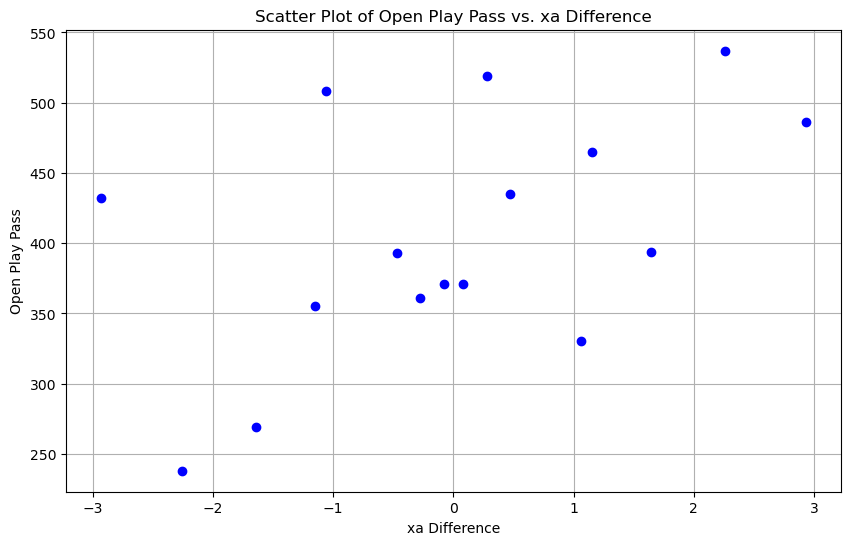

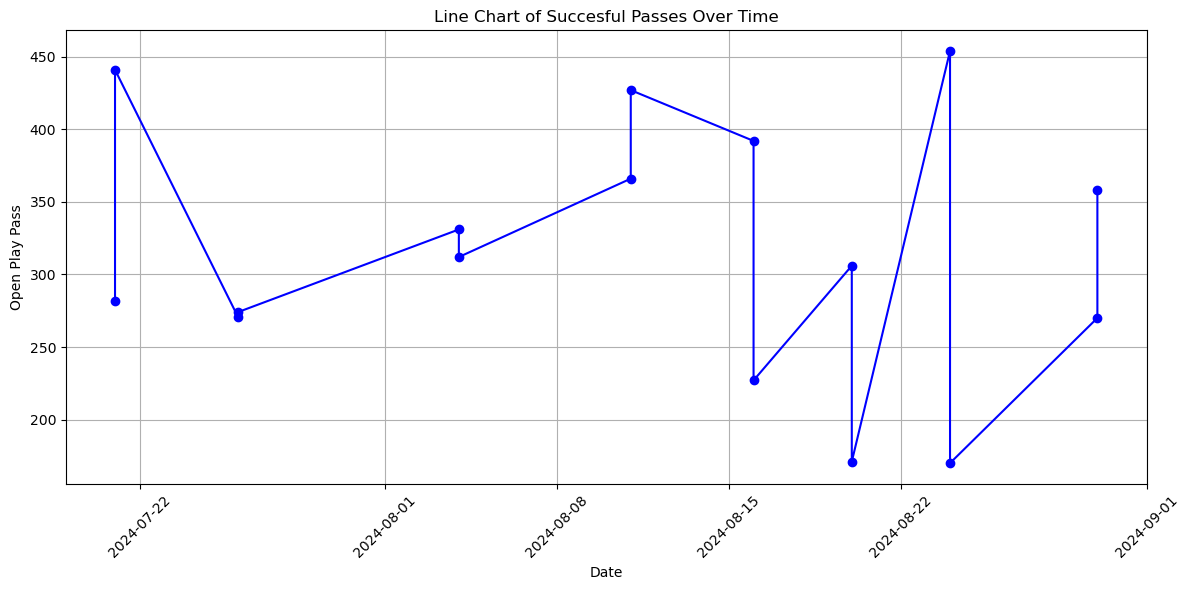

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df_horsens['xA diff'], df_horsens['openPlayPass'], color='b', marker='o')

# Add labels and title
plt.xlabel('xa Difference')
plt.ylabel('Open Play Pass')
plt.title('Scatter Plot of Open Play Pass vs. xa Difference')

# Show the plot
plt.grid(True)
plt.show()


df_horsens['date'] = pd.to_datetime(df_horsens['date'])
df_horsens = df_horsens.sort_values('date')
# Create the line chart
plt.figure(figsize=(12, 6))
plt.plot(df_horsens['date'], df_horsens['successfulOpenPlayPass'], marker='o', linestyle='-', color='b')

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Open Play Pass')
plt.title('Line Chart of Succesful Passes Over Time')

# Show the plot
plt.grid(True)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to fit labels and title
plt.show()

